# Project description

Sweet Lift Taxi company has collected historical data on taxi orders at airports. To attract more drivers during peak hours, we need to predict the amount of taxi orders for the next hour. Build a model for such a prediction.

The RMSE metric on the test set should not be more than 48.

### Project instructions

1. Download the data and resample it by one hour.
2. Analyze the data.
3. Train different models with different hyperparameters. The test sample should be 10% of the initial dataset. 
4. Test the data using the test sample and provide a conclusion.

### Data description

The data is stored in the `taxi.csv` file. The number of orders is in the '*num_orders*' column.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Data preparation

In [2]:
data = pd.read_csv('taxi.csv', parse_dates=[0], index_col=[0])
print(data.shape)
data.head()

(26496, 1)


,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


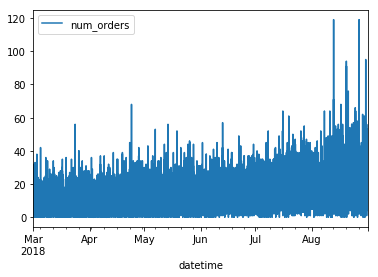

In [3]:
data.plot()

In [4]:
data = data.resample('1H').sum()

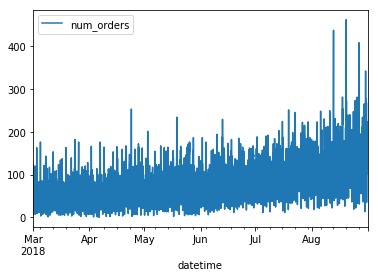

In [5]:
data.plot()

In [6]:
print(data.shape)

(4416, 1)


# 2. Analysis

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

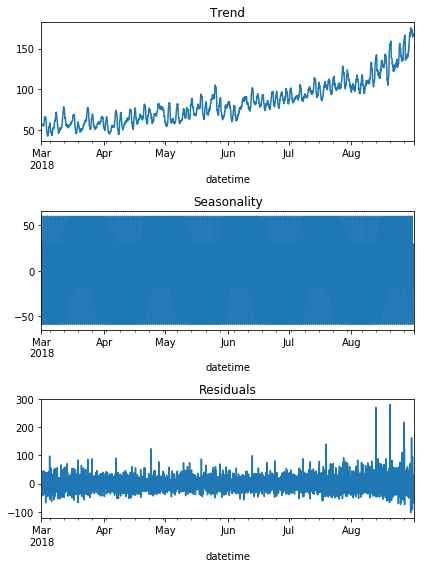

In [8]:
decomposed = seasonal_decompose(data)

plt.figure(figsize=(6, 8))
plt.subplot(311)
decomposed.trend.plot(ax=plt.gca())
plt.title('Trend')
plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca())
plt.title('Seasonality')
plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.title('Residuals')
plt.tight_layout()

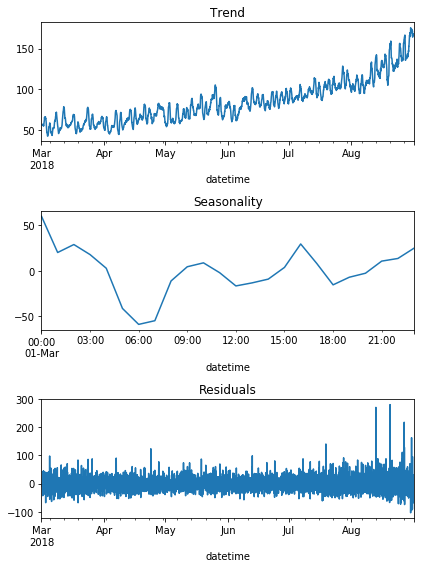

In [9]:
plt.figure(figsize=(6, 8))
plt.subplot(311)
decomposed.trend.plot(ax=plt.gca())
plt.title('Trend')
plt.subplot(312)
decomposed.seasonal['1 March 2018'].plot(ax=plt.gca())
plt.title('Seasonality')
plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.title('Residuals')
plt.tight_layout()

**Findings:** There is an obvious six-month trend of increasing number of orders. Also one-day seasonality can be observed: at around 6 a.m. the number of orders is minimal due to small number of flights in the morning. The maximum is observed around midnight (a lot of arriving flights, other modes of transportation are unavailable).

# 3. Training

In [10]:
def make_features(data, max_lag=4, rolling_mean_size=10):
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek_num'] = data.index.dayofweek
    data['hour'] = data.index.hour

    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)
        
    data['rolling_mean'] = data['num_orders'].shift().rolling(rolling_mean_size).mean()


make_features(data)
data = data.dropna()
print(data.shape)
data.head()

(4406, 10)


,num_orders,month,day,dayofweek_num,hour,lag_1,lag_2,lag_3,lag_4,rolling_mean
datetime,,,,,,,,,,
2018-03-01 10:00:00,64,3,1,3,10,69.0,34.0,15.0,12.0,52.5
2018-03-01 11:00:00,96,3,1,3,11,64.0,69.0,34.0,15.0,46.5
2018-03-01 12:00:00,30,3,1,3,12,96.0,64.0,69.0,34.0,47.6
2018-03-01 13:00:00,32,3,1,3,13,30.0,96.0,64.0,69.0,43.5
2018-03-01 14:00:00,48,3,1,3,14,32.0,30.0,96.0,64.0,40.1


In [11]:
from sklearn.model_selection import train_test_split

train_valid, test = train_test_split(data, shuffle=False, test_size=0.1)
train, valid = train_test_split(train_valid, shuffle=False, test_size=0.1)

print(train.index.min(), train.index.max())
print(train.shape)
print(valid.index.min(), valid.index.max())
print(valid.shape)
print(test.index.min(), test.index.max())
print(test.shape)

2018-03-01 10:00:00 2018-07-28 01:00:00
(3568, 10)
2018-07-28 02:00:00 2018-08-13 14:00:00
(397, 10)
2018-08-13 15:00:00 2018-08-31 23:00:00
(441, 10)


In [12]:
features_train = train.drop(['num_orders'], axis=1)
target_train = train['num_orders']
features_valid = valid.drop(['num_orders'], axis=1)
target_valid = valid['num_orders']
features_test = test.drop(['num_orders'], axis=1)
target_test = test['num_orders']

In [13]:
from sklearn.metrics import mean_squared_error

def rmse(true, pred):
    return mean_squared_error(true, pred)**0.5


print('Mean value:', test['num_orders'].mean())
pred_previous = test.shift()
pred_previous.iloc[0] = train.iloc[-1]
print('RMSE prev:', rmse(test['num_orders'], pred_previous['num_orders']))
pred_mean = np.ones(test['num_orders'].shape) * train['num_orders'].mean()
print('RMSE mean:', rmse(test['num_orders'], pred_mean))

Mean value: 139.64172335600907
RMSE prev: 58.82268986995932
RMSE mean: 87.35030729608127


In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(features_train, target_train)

pred_train = model.predict(features_train)
pred_valid = model.predict(features_valid)

print("RMSE train:", rmse(target_train, pred_train))
print("RMSE valid:", rmse(target_valid, pred_valid))

RMSE train: 29.189032950503787
RMSE valid: 40.53857656513466


In [15]:
%%time

from sklearn.ensemble import RandomForestRegressor

for max_depth in [2, 4, 6, 8, 10, 12, None]:
    model = RandomForestRegressor(n_estimators=500, max_depth=max_depth)
    model.fit(features_train, target_train)

    pred_train = model.predict(features_train)
    pred_valid = model.predict(features_valid)

    print('max_depth =', max_depth)
    print("RMSE train:", rmse(target_train, pred_train))
    print("RMSE valid:", rmse(target_valid, pred_valid))
    print()

max_depth = 2
RMSE train: 28.68303710974008
RMSE valid: 48.045851033192456

max_depth = 4
RMSE train: 24.8593170802844
RMSE valid: 41.208219919472384

max_depth = 6
RMSE train: 21.2100466072196
RMSE valid: 35.317349389208594

max_depth = 8
RMSE train: 17.627885833665452
RMSE valid: 33.19752179853017

max_depth = 10
RMSE train: 14.136544878261594
RMSE valid: 32.231788138951615

max_depth = 12
RMSE train: 11.243221644309447
RMSE valid: 31.782586946781848

max_depth = None
RMSE train: 7.777547343579102
RMSE valid: 31.676702116179627

CPU times: user 31.8 s, sys: 537 ms, total: 32.4 s
Wall time: 35.3 s


In [16]:
%%time

from lightgbm import LGBMRegressor

model = LGBMRegressor(learning_rate=0.02, num_iterations=2000, objective='rmse')
model.fit(features_train, target_train, 
          eval_set=(features_valid, target_valid))

pred_train = model.predict(features_train)
pred_valid = model.predict(features_valid)

print("RMSE train:", rmse(target_train, pred_train))
print("RMSE valid:", rmse(target_valid, pred_valid))

[1]	valid_0's rmse: 57.2639
[2]	valid_0's rmse: 56.7064
[3]	valid_0's rmse: 56.1298
[4]	valid_0's rmse: 55.5829
[5]	valid_0's rmse: 55.0435
[6]	valid_0's rmse: 54.5197
[7]	valid_0's rmse: 53.9929
[8]	valid_0's rmse: 53.51
[9]	valid_0's rmse: 53.0407
[10]	valid_0's rmse: 52.5864
[11]	valid_0's rmse: 52.1281
[12]	valid_0's rmse: 51.668
[13]	valid_0's rmse: 51.2297
[14]	valid_0's rmse: 50.7866
[15]	valid_0's rmse: 50.3713
[16]	valid_0's rmse: 49.9744
[17]	valid_0's rmse: 49.557
[18]	valid_0's rmse: 49.1552
[19]	valid_0's rmse: 48.7643
[20]	valid_0's rmse: 48.394
[21]	valid_0's rmse: 48.0329
[22]	valid_0's rmse: 47.6832
[23]	valid_0's rmse: 47.3318


/usr/local/lib/python3.7/site-packages/lightgbm/__init__.py:46: UserWarning: Starting from version 2.2.1, the library file in distribution wheels for macOS is built by the Apple Clang (Xcode_8.3.3) compiler.
This means that in case of installing LightGBM from PyPI via the ``pip install lightgbm`` command, you don't need to install the gcc compiler anymore.
Instead of that, you need to install the OpenMP library, which is required for running LightGBM on the system with the Apple Clang compiler.
You can install the OpenMP library by the following command: ``brew install libomp``.
  "You can install the OpenMP library by the following command: ``brew install libomp``.", UserWarning)
/usr/local/lib/python3.7/site-packages/lightgbm/engine.py:118: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  warnings.warn("Found `{}` in params. Will use it instead of argument".format(alias))


[24]	valid_0's rmse: 47.0128
[25]	valid_0's rmse: 46.7101
[26]	valid_0's rmse: 46.3896
[27]	valid_0's rmse: 46.0539
[28]	valid_0's rmse: 45.7437
[29]	valid_0's rmse: 45.4202
[30]	valid_0's rmse: 45.1026
[31]	valid_0's rmse: 44.8234
[32]	valid_0's rmse: 44.516
[33]	valid_0's rmse: 44.22
[34]	valid_0's rmse: 43.9504
[35]	valid_0's rmse: 43.7075
[36]	valid_0's rmse: 43.4062
[37]	valid_0's rmse: 43.1618
[38]	valid_0's rmse: 42.8762
[39]	valid_0's rmse: 42.6126
[40]	valid_0's rmse: 42.3954
[41]	valid_0's rmse: 42.2012
[42]	valid_0's rmse: 41.9381
[43]	valid_0's rmse: 41.7245
[44]	valid_0's rmse: 41.5266
[45]	valid_0's rmse: 41.3523
[46]	valid_0's rmse: 41.1829
[47]	valid_0's rmse: 40.9898
[48]	valid_0's rmse: 40.7857
[49]	valid_0's rmse: 40.607
[50]	valid_0's rmse: 40.4512
[51]	valid_0's rmse: 40.2648
[52]	valid_0's rmse: 40.0943
[53]	valid_0's rmse: 39.9279
[54]	valid_0's rmse: 39.7671
[55]	valid_0's rmse: 39.5945
[56]	valid_0's rmse: 39.4452
[57]	valid_0's rmse: 39.3179
[58]	valid_0's rms

[315]	valid_0's rmse: 32.0373
[316]	valid_0's rmse: 32.0369
[317]	valid_0's rmse: 32.0407
[318]	valid_0's rmse: 32.0488
[319]	valid_0's rmse: 32.042
[320]	valid_0's rmse: 32.0349
[321]	valid_0's rmse: 32.0367
[322]	valid_0's rmse: 32.0312
[323]	valid_0's rmse: 32.0246
[324]	valid_0's rmse: 32.0359
[325]	valid_0's rmse: 32.0265
[326]	valid_0's rmse: 32.0182
[327]	valid_0's rmse: 32.0268
[328]	valid_0's rmse: 32.0181
[329]	valid_0's rmse: 32.0183
[330]	valid_0's rmse: 32.0114
[331]	valid_0's rmse: 32.0179
[332]	valid_0's rmse: 32.0151
[333]	valid_0's rmse: 32.0252
[334]	valid_0's rmse: 32.0181
[335]	valid_0's rmse: 32.0288
[336]	valid_0's rmse: 32.0207
[337]	valid_0's rmse: 32.0162
[338]	valid_0's rmse: 32.0219
[339]	valid_0's rmse: 32.0254
[340]	valid_0's rmse: 32.0247
[341]	valid_0's rmse: 32.0196
[342]	valid_0's rmse: 32.0251
[343]	valid_0's rmse: 32.0248
[344]	valid_0's rmse: 32.0318
[345]	valid_0's rmse: 32.0345
[346]	valid_0's rmse: 32.0405
[347]	valid_0's rmse: 32.0327
[348]	valid

[655]	valid_0's rmse: 32.2186
[656]	valid_0's rmse: 32.2134
[657]	valid_0's rmse: 32.2198
[658]	valid_0's rmse: 32.2197
[659]	valid_0's rmse: 32.218
[660]	valid_0's rmse: 32.2206
[661]	valid_0's rmse: 32.2201
[662]	valid_0's rmse: 32.2184
[663]	valid_0's rmse: 32.2175
[664]	valid_0's rmse: 32.2218
[665]	valid_0's rmse: 32.2226
[666]	valid_0's rmse: 32.2227
[667]	valid_0's rmse: 32.2201
[668]	valid_0's rmse: 32.2153
[669]	valid_0's rmse: 32.2201
[670]	valid_0's rmse: 32.22
[671]	valid_0's rmse: 32.2187
[672]	valid_0's rmse: 32.2255
[673]	valid_0's rmse: 32.2243
[674]	valid_0's rmse: 32.2295
[675]	valid_0's rmse: 32.2334
[676]	valid_0's rmse: 32.2317
[677]	valid_0's rmse: 32.2297
[678]	valid_0's rmse: 32.2278
[679]	valid_0's rmse: 32.2277
[680]	valid_0's rmse: 32.2343
[681]	valid_0's rmse: 32.2353
[682]	valid_0's rmse: 32.2363
[683]	valid_0's rmse: 32.2367
[684]	valid_0's rmse: 32.2376
[685]	valid_0's rmse: 32.2349
[686]	valid_0's rmse: 32.2359
[687]	valid_0's rmse: 32.2345
[688]	valid_0

[935]	valid_0's rmse: 32.4557
[936]	valid_0's rmse: 32.456
[937]	valid_0's rmse: 32.4566
[938]	valid_0's rmse: 32.4578
[939]	valid_0's rmse: 32.4554
[940]	valid_0's rmse: 32.458
[941]	valid_0's rmse: 32.46
[942]	valid_0's rmse: 32.4617
[943]	valid_0's rmse: 32.4598
[944]	valid_0's rmse: 32.458
[945]	valid_0's rmse: 32.4629
[946]	valid_0's rmse: 32.4627
[947]	valid_0's rmse: 32.4645
[948]	valid_0's rmse: 32.4635
[949]	valid_0's rmse: 32.462
[950]	valid_0's rmse: 32.4599
[951]	valid_0's rmse: 32.464
[952]	valid_0's rmse: 32.4641
[953]	valid_0's rmse: 32.4629
[954]	valid_0's rmse: 32.4684
[955]	valid_0's rmse: 32.4702
[956]	valid_0's rmse: 32.4711
[957]	valid_0's rmse: 32.4703
[958]	valid_0's rmse: 32.4718
[959]	valid_0's rmse: 32.4744
[960]	valid_0's rmse: 32.4746
[961]	valid_0's rmse: 32.4767
[962]	valid_0's rmse: 32.473
[963]	valid_0's rmse: 32.4717
[964]	valid_0's rmse: 32.4741
[965]	valid_0's rmse: 32.475
[966]	valid_0's rmse: 32.4773
[967]	valid_0's rmse: 32.4752
[968]	valid_0's rms

[1285]	valid_0's rmse: 32.6318
[1286]	valid_0's rmse: 32.6327
[1287]	valid_0's rmse: 32.6342
[1288]	valid_0's rmse: 32.6362
[1289]	valid_0's rmse: 32.6358
[1290]	valid_0's rmse: 32.6339
[1291]	valid_0's rmse: 32.6341
[1292]	valid_0's rmse: 32.6314
[1293]	valid_0's rmse: 32.6343
[1294]	valid_0's rmse: 32.6331
[1295]	valid_0's rmse: 32.632
[1296]	valid_0's rmse: 32.6349
[1297]	valid_0's rmse: 32.6323
[1298]	valid_0's rmse: 32.6347
[1299]	valid_0's rmse: 32.6373
[1300]	valid_0's rmse: 32.6375
[1301]	valid_0's rmse: 32.6374
[1302]	valid_0's rmse: 32.6361
[1303]	valid_0's rmse: 32.6341
[1304]	valid_0's rmse: 32.6344
[1305]	valid_0's rmse: 32.638
[1306]	valid_0's rmse: 32.6382
[1307]	valid_0's rmse: 32.6365
[1308]	valid_0's rmse: 32.6369
[1309]	valid_0's rmse: 32.6432
[1310]	valid_0's rmse: 32.6416
[1311]	valid_0's rmse: 32.6402
[1312]	valid_0's rmse: 32.6404
[1313]	valid_0's rmse: 32.6407
[1314]	valid_0's rmse: 32.6414
[1315]	valid_0's rmse: 32.6408
[1316]	valid_0's rmse: 32.6411
[1317]	val

[1582]	valid_0's rmse: 32.6899
[1583]	valid_0's rmse: 32.6902
[1584]	valid_0's rmse: 32.6895
[1585]	valid_0's rmse: 32.6897
[1586]	valid_0's rmse: 32.6868
[1587]	valid_0's rmse: 32.6864
[1588]	valid_0's rmse: 32.6873
[1589]	valid_0's rmse: 32.6876
[1590]	valid_0's rmse: 32.6871
[1591]	valid_0's rmse: 32.6876
[1592]	valid_0's rmse: 32.6881
[1593]	valid_0's rmse: 32.689
[1594]	valid_0's rmse: 32.6874
[1595]	valid_0's rmse: 32.6873
[1596]	valid_0's rmse: 32.6889
[1597]	valid_0's rmse: 32.6887
[1598]	valid_0's rmse: 32.6885
[1599]	valid_0's rmse: 32.6893
[1600]	valid_0's rmse: 32.6876
[1601]	valid_0's rmse: 32.6883
[1602]	valid_0's rmse: 32.6892
[1603]	valid_0's rmse: 32.6899
[1604]	valid_0's rmse: 32.6909
[1605]	valid_0's rmse: 32.6914
[1606]	valid_0's rmse: 32.6897
[1607]	valid_0's rmse: 32.6915
[1608]	valid_0's rmse: 32.6923
[1609]	valid_0's rmse: 32.6924
[1610]	valid_0's rmse: 32.6925
[1611]	valid_0's rmse: 32.6892
[1612]	valid_0's rmse: 32.6913
[1613]	valid_0's rmse: 32.6927
[1614]	va

[1858]	valid_0's rmse: 32.7897
[1859]	valid_0's rmse: 32.7889
[1860]	valid_0's rmse: 32.7889
[1861]	valid_0's rmse: 32.7888
[1862]	valid_0's rmse: 32.789
[1863]	valid_0's rmse: 32.7889
[1864]	valid_0's rmse: 32.7881
[1865]	valid_0's rmse: 32.7875
[1866]	valid_0's rmse: 32.7862
[1867]	valid_0's rmse: 32.7862
[1868]	valid_0's rmse: 32.786
[1869]	valid_0's rmse: 32.7863
[1870]	valid_0's rmse: 32.7878
[1871]	valid_0's rmse: 32.7866
[1872]	valid_0's rmse: 32.7854
[1873]	valid_0's rmse: 32.7866
[1874]	valid_0's rmse: 32.7868
[1875]	valid_0's rmse: 32.788
[1876]	valid_0's rmse: 32.7869
[1877]	valid_0's rmse: 32.7873
[1878]	valid_0's rmse: 32.7859
[1879]	valid_0's rmse: 32.7882
[1880]	valid_0's rmse: 32.7911
[1881]	valid_0's rmse: 32.7919
[1882]	valid_0's rmse: 32.7908
[1883]	valid_0's rmse: 32.7908
[1884]	valid_0's rmse: 32.7913
[1885]	valid_0's rmse: 32.7952
[1886]	valid_0's rmse: 32.7957
[1887]	valid_0's rmse: 32.797
[1888]	valid_0's rmse: 32.7975
[1889]	valid_0's rmse: 32.7997
[1890]	valid

In [17]:
%%time

from catboost import CatBoostRegressor

model = CatBoostRegressor(iterations=2000,
                          learning_rate=0.02,
                          metric_period=100,
                          loss_function='RMSE')

model.fit(features_train, target_train, 
          eval_set=(features_valid, target_valid))

pred_train = model.predict(features_train)
pred_valid = model.predict(features_valid)

print("RMSE train:", rmse(target_train, pred_train))
print("RMSE valid:", rmse(target_valid, pred_valid))

0:	learn: 81.6791843	test: 117.4683007	best: 117.4683007 (0)	total: 72.6ms	remaining: 2m 25s
100:	learn: 27.2184791	test: 47.1880490	best: 47.1880490 (100)	total: 994ms	remaining: 18.7s
200:	learn: 22.6121863	test: 37.3447165	best: 37.3447165 (200)	total: 1.77s	remaining: 15.9s
300:	learn: 21.4763793	test: 34.9362854	best: 34.9362854 (300)	total: 3.8s	remaining: 21.5s
400:	learn: 20.7743104	test: 33.8682642	best: 33.8682642 (400)	total: 4.47s	remaining: 17.8s
500:	learn: 20.2686510	test: 33.2538240	best: 33.2538240 (500)	total: 7.87s	remaining: 23.6s
600:	learn: 19.8827190	test: 32.8160208	best: 32.8160208 (600)	total: 10.6s	remaining: 24.8s
700:	learn: 19.5713289	test: 32.6129243	best: 32.6129243 (700)	total: 11.5s	remaining: 21.4s
800:	learn: 19.3184249	test: 32.4975405	best: 32.4975405 (800)	total: 12.4s	remaining: 18.6s
900:	learn: 19.1046680	test: 32.4018500	best: 32.4018500 (900)	total: 13.2s	remaining: 16.1s
1000:	learn: 18.9118854	test: 32.2862167	best: 32.2862167 (1000)	total:

# 4. Testing

In [18]:
features_train_valid = train_valid.drop(['num_orders'], axis=1)
target_train_valid = train_valid['num_orders']

In [19]:
model = LinearRegression()

model.fit(features_train_valid, target_train_valid)

pred_train = model.predict(features_train_valid)
print("RMSE train:", rmse(target_train_valid, pred_train))

pred_test = model.predict(features_test)
print("RMSE test:", rmse(target_test, pred_test))

RMSE train: 30.489333305784672
RMSE test: 53.17801688053662


In [20]:
model = RandomForestRegressor(n_estimators=500)

model.fit(features_train_valid, target_train_valid)

pred_train = model.predict(features_train_valid)
print("RMSE train:", rmse(target_train_valid, pred_train))

pred_test = model.predict(features_test)
print("RMSE test:", rmse(target_test, pred_test))

RMSE train: 8.2195259308625
RMSE test: 46.09103481278522


In [21]:
model = CatBoostRegressor(iterations=2000,
                          learning_rate=0.02,
                          loss_function='RMSE',
                          verbose=False)

model.fit(features_train_valid, target_train_valid)

pred_train = model.predict(features_train_valid)
print("RMSE train:", rmse(target_train_valid, pred_train))

pred_test = model.predict(features_test)
print("RMSE test:", rmse(target_test, pred_test))

RMSE train: 19.682330181283884
RMSE test: 48.96868502889873


**Findings:**

1) The quality between train and test doesn't differ significantly

2) Random forrest works the best